# Lasso Regression example

### For linear Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

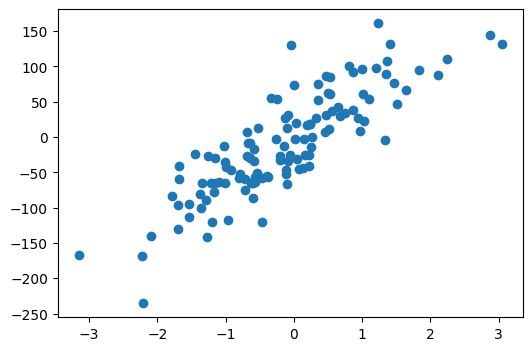

In [34]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

x, y = make_regression(n_samples=120, n_features=1, n_informative=1, n_targets=1, noise=40, random_state=12)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)
plt.figure(figsize=(6,4))
plt.scatter(x, y)

In [35]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

print("Coefficient -",lr.coef_)
print("Intercept -",lr.intercept_)

Coefficient - [58.12843027]
Intercept - 0.7225956181022424


Alpha: 0
Coefficient: [58.12843027]
Intercept: 0.7225956181022433

Alpha: 1
Coefficient: [57.3403216]
Intercept: 0.6296601755198168

Alpha: 5
Coefficient: [54.18788695]
Intercept: 0.25791840519011

Alpha: 10
Coefficient: [50.24734362]
Intercept: -0.20675880772202238

Alpha: 30
Coefficient: [34.48517032]
Intercept: -2.0654676593705528



E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.523e+04, tolerance: 5.620e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


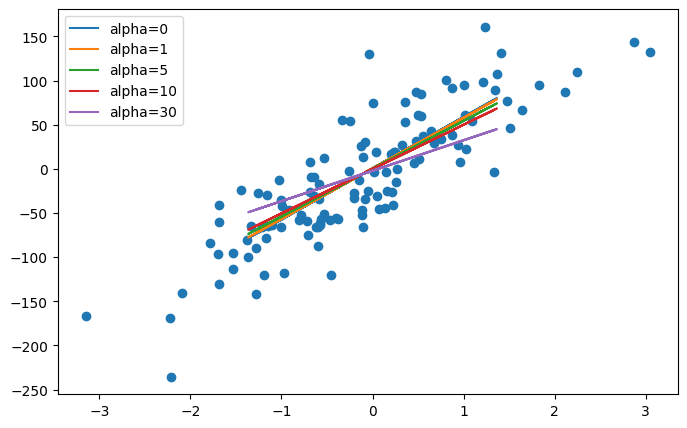

In [46]:
from sklearn.linear_model import Lasso
alphas = [0, 1, 5, 10, 30]

plt.figure(figsize=(8,5))
plt.scatter(x, y)

for i in alphas:
    L = Lasso(alpha=i)
    L.fit(x_train, y_train)
    print('Alpha:', i)
    print('Coefficient:', L.coef_)
    print('Intercept:', L.intercept_)
    print()
    plt.plot(x_test, L.predict(x_test), label="alpha={}".format(i))

plt.legend()
plt.show()

### For non-linear Dataset

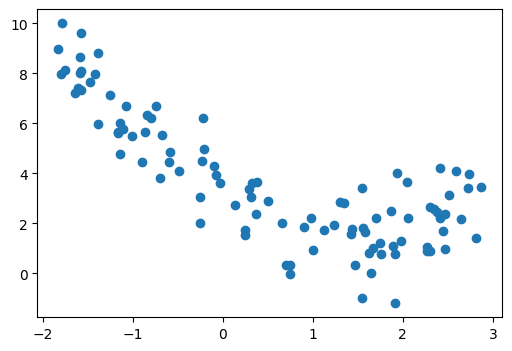

In [38]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2*x1 + 3 + np.random.randn(m, 1)

plt.figure(figsize=(6, 4))
plt.scatter(x1, x2)
plt.show()

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.401e+01, tolerance: 6.620e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
E:\Anacon

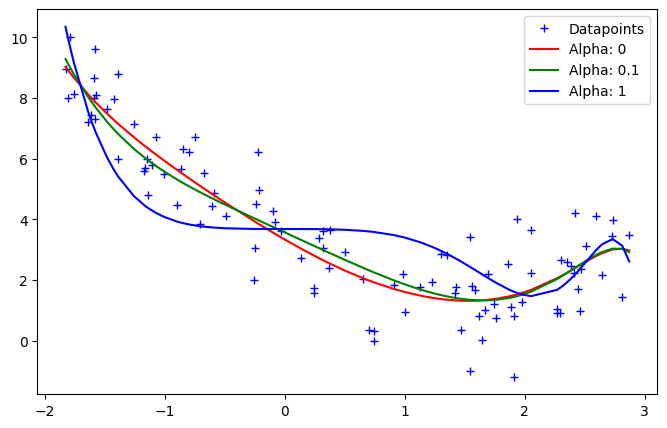

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=12)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(8,5))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c, label="Alpha: {}".format(alpha))

plt.legend()
plt.show()